In [1]:
import cv2
import mediapipe as mp
import numpy as np
import matplotlib.pyplot as plt

In [2]:
mp_hands = mp.solutions.hands
mp_draw = mp.solutions.drawing_utils

In [3]:
def extract_keypoints(results):
    if not results.multi_hand_landmarks:
        return np.zeros(21*3)

    hand_landmarks = results.multi_hand_landmarks[0]

    keypoints = []
    for lm in hand_landmarks.landmark:
        keypoints.append(lm.x)
        keypoints.append(lm.y)
        keypoints.append(lm.z)

    return np.array(keypoints)

In [4]:
import os
os.makedirs('dataset/true', exist_ok=True)
os.makedirs('dataset/false', exist_ok=True)

In [5]:
from sklearn.model_selection import train_test_split
from collections import Counter

In [6]:
def load_npy_folder(folder):
    files = sorted([os.path.join(folder, f) for f in os.listdir(folder) if f.endswith('.npy')])
    data = []
    for f in files:
        try:
            arr = np.load(f)
            data.append(arr)
        except Exception as e:
            print(f"Couldn't load {f}: {e}")
    return data

In [7]:
TRUE_DIR = "dataset/true"
FALSE_DIR = "dataset/false"

true_samples = load_npy_folder(TRUE_DIR)
false_samples = load_npy_folder(FALSE_DIR)

In [8]:
X_true = np.vstack(true_samples) if len(true_samples) else np.empty((0, 63))
X_false = np.vstack(false_samples) if len(false_samples) else np.empty((0, 63))
y_true = np.ones(len(X_true), dtype=np.int32)
y_false = np.zeros(len(X_false), dtype=np.int32)

In [9]:
X = np.vstack([X_true, X_false])
y = np.concatenate([y_true, y_false])

In [10]:
TEST_SIZE = 0.2
RANDOM_STATE = 42

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, shuffle=True, stratify=y
)

# KNN

In [11]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(
    n_neighbors=5,
    metric='euclidean'
)

knn.fit(X_train, y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'euclidean'
,metric_params,None
,n_jobs,None


In [12]:
y_pred_knn = knn.predict(X_test)

In [13]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

acc_knn  = accuracy_score(y_test, y_pred_knn)
prec_knn = precision_score(y_test, y_pred_knn)
rec_knn  = recall_score(y_test, y_pred_knn)
f1_knn   = f1_score(y_test, y_pred_knn)

print("KNN Results")
print("Accuracy :", acc_knn)
print("Precision:", prec_knn)
print("Recall   :", rec_knn)
print("F1 Score :", f1_knn)


KNN Results
Accuracy : 0.9457831325301205
Precision: 0.9130434782608695
Recall   : 0.9882352941176471
F1 Score : 0.9491525423728814


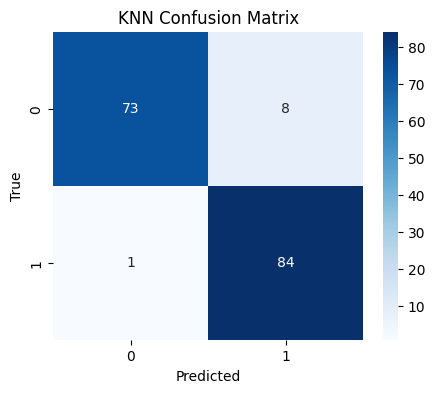

In [14]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm_knn = confusion_matrix(y_test, y_pred_knn)

plt.figure(figsize=(5,4))
sns.heatmap(cm_knn, annot=True, fmt="d", cmap="Blues")
plt.title("KNN Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()


# SVM

In [15]:
from sklearn.svm import SVC

svm = SVC(
    kernel='rbf',
    C=1.0,
    gamma='scale',
    probability=True,
    random_state=42
)

svm.fit(X_train, y_train)

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,True
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [16]:
y_pred_svm = svm.predict(X_test)

In [17]:
acc_svm  = accuracy_score(y_test, y_pred_svm)
prec_svm = precision_score(y_test, y_pred_svm)
rec_svm  = recall_score(y_test, y_pred_svm)
f1_svm   = f1_score(y_test, y_pred_svm)

print("SVM Results")
print("Accuracy :", acc_svm)
print("Precision:", prec_svm)
print("Recall   :", rec_svm)
print("F1 Score :", f1_svm)


SVM Results
Accuracy : 0.9698795180722891
Precision: 0.9545454545454546
Recall   : 0.9882352941176471
F1 Score : 0.9710982658959537


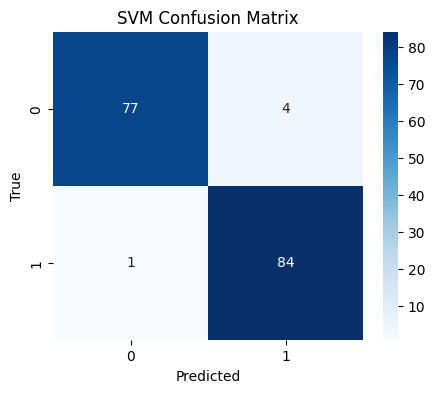

In [18]:
cm_svm = confusion_matrix(y_test, y_pred_svm)

plt.figure(figsize=(5,4))
sns.heatmap(cm_svm, annot=True, fmt="d", cmap="Blues")
plt.title("SVM Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()
